# Fair PCA — Comparação Experimental

Notebook para comparar experimentalmente **seis** algoritmos de redução de dimensionalidade justa (*Fair PCA*):

1. **PCA clássico**
2. **Fair PCA clássico** (combinação linear fixa entre covariância global e diferença de covariâncias dos grupos)
3. **U-FPCA** (Unconstrained Fair PCA — Pelegrina & Duarte), busca de α que minimiza o quadrado da disparidade
4. **C-FPCA** (Constrained Fair PCA — Pelegrina & Duarte), idem, sujeito a `R_A(U) ≤ τ` e `R_B(U) ≤ τ`
5. **Barganha U-FPCA** (proposto): solução de Nash ponderada sobre utilidades `u_g = 1/R_g(U)`, otimizada na variedade de Stiefel
6. **Barganha C-FPCA** (proposto): solução de Nash ponderada sobre utilidades `u_g = -R_g(U)`, com ponto de desacordo `d_g = -τ`, otimizada na variedade de Stiefel

O notebook é modular: basta trocar as configurações da **Seção 3** para rodar com outro dataset/coluna sensível.

> **Nota de implementação:** `pymanopt`/`cvxpy` não são pré-requisitos — a otimização Riemanniana (gradiente + retração QR + Armijo) e a busca em α (seção áurea) são implementadas apenas com NumPy/SciPy, o que torna o notebook autocontido.


## 1. Instalação das bibliotecas

In [24]:
# Todas as dependências usadas neste notebook são bibliotecas científicas padrão.
# Descomente a linha abaixo caso alguma não esteja instalada no seu ambiente.

# %pip install numpy scipy pandas matplotlib scikit-learn


## 2. Imports

In [25]:
import time
import warnings
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
np.set_printoptions(precision=4, suppress=True)

RNG = np.random.default_rng(42)


## 2.1 Diagnóstico do CSV (rode antes de preencher a Seção 3)

Antes de fixar `COLUMN_NAMES` / `GROUP_COLUMN` no `CONFIG`, é melhor inspecionar o
CSV cru: assim você identifica, pela posição, qual coluna é o atributo sensível
(deve ter poucos valores distintos — ex.: 2 categorias) em vez de adivinhar pelo
nome. Edite `CAMINHO_CSV` e `TEM_CABECALHO` abaixo e rode a célula.


In [26]:
CAMINHO_CSV   = "lsac.csv"   # troque para o arquivo que quer inspecionar
TEM_CABECALHO = False        # True se a 1a linha do CSV já for o cabeçalho

_df_raw = pd.read_csv(CAMINHO_CSV, header=0 if TEM_CABECALHO else None)
if not TEM_CABECALHO:
    _df_raw.columns = [f"col{i}" for i in range(_df_raw.shape[1])]

print(f"{_df_raw.shape[0]} linhas, {_df_raw.shape[1]} colunas\n")
diag_rows = []
for c in _df_raw.columns:
    serie = _df_raw[c]
    nun = serie.nunique(dropna=True)
    diag_rows.append(dict(
        coluna=c,
        n_valores_unicos=nun,
        exemplo_valores=sorted(serie.dropna().unique())[:6],
        min=serie.min() if pd.api.types.is_numeric_dtype(serie) else None,
        max=serie.max() if pd.api.types.is_numeric_dtype(serie) else None,
    ))
diag_df = pd.DataFrame(diag_rows)
print("Colunas com poucos valores distintos são as candidatas a atributo sensível")
print("(ex.: sexo, raça, escolaridade costumam ter 2 a 5 valores únicos):\n")
display(diag_df.sort_values("n_valores_unicos"))


26551 linhas, 12 colunas

Colunas com poucos valores distintos são as candidatas a atributo sensível
(ex.: sexo, raça, escolaridade costumam ter 2 a 5 valores únicos):



,coluna,n_valores_unicos,exemplo_valores,min,max
3,col3,2,"[1, 2]",1.000000,2.000000
4,col4,2,"[1, 2]",1.000000,2.000000
11,col11,2,"[0, 1]",0.000000,1.000000
5,col5,3,"[1, 2, 3]",1.000000,3.000000
7,col7,5,"[1, 2, 3, 4, 5]",1.000000,5.000000
6,col6,6,"[1, 2, 3, 4, 5, 6]",1.000000,6.000000
9,col9,26,"[1.5, 1.6, 1.7, 1.8, 1.9, 2.0]",1.500000,4.000000
2,col2,55,"[0, 10, 12, 14, 15, 16]",0.000000,72.000000
8,col8,118,"[11.0, 12.0, 13.5, 14.0, 14.5, 15.0]",11.000000,48.000000
1,col1,598,"[-6.44, -3.46, -3.27, -3.21, -3.19, -3.16]",-6.440000,4.010000


### 2.2 Identificando a coluna de raça pela proporção conhecida (LSAC)

O artigo reporta a divisão exata do atributo sensível nessa base: **1790 amostras
"black" vs. 24761 "white + other"** (~6,7% vs. ~93,3%). Em vez de adivinhar pelo
nome/posição, comparamos essa proporção com a de cada coluna categórica candidata
— a que mais se aproxima de 6,7%/93,3% é a coluna de raça.


In [27]:
PROPORCAO_MINORIA_PAPER = 1790 / (1790 + 24761)  # ~0.0674

candidatas = [c for c in _df_raw.columns if _df_raw[c].nunique(dropna=True) <= 6]

print(f"Proporção esperada da categoria minoritária (paper): {PROPORCAO_MINORIA_PAPER:.4f}\n")
print("Distribuição de cada coluna candidata (categórica, poucos valores únicos):\n")

melhor_col, melhor_dist = None, np.inf
for c in candidatas:
    vc = _df_raw[c].value_counts(normalize=True).sort_values()
    prop_minoria = vc.iloc[0]
    dist = abs(prop_minoria - PROPORCAO_MINORIA_PAPER)
    marca = "  <-- candidata a 'race'" if dist < 0.03 else ""
    print(f"{c}: {dict(vc.round(4))}{marca}")
    if dist < melhor_dist:
        melhor_col, melhor_dist = c, dist

print(f"\nColuna mais compatível com a proporção de raça do paper: '{melhor_col}' "
      f"(diferença de {melhor_dist:.4f})")


Proporção esperada da categoria minoritária (paper): 0.0674

Distribuição de cada coluna candidata (categórica, poucos valores únicos):

col3: {1: np.float64(0.0895), 2: np.float64(0.9105)}  <-- candidata a 'race'
col4: {2: np.float64(0.4398), 1: np.float64(0.5602)}
col5: {2: np.float64(0.0674), 3: np.float64(0.1064), 1: np.float64(0.8262)}  <-- candidata a 'race'
col6: {1: np.float64(0.0277), 2: np.float64(0.0816), 6: np.float64(0.0876), 5: np.float64(0.1714), 4: np.float64(0.2767), 3: np.float64(0.3549)}
col7: {1: np.float64(0.0245), 5: np.float64(0.079), 2: np.float64(0.1062), 3: np.float64(0.3648), 4: np.float64(0.4254)}
col11: {0: np.float64(0.199), 1: np.float64(0.801)}

Coluna mais compatível com a proporção de raça do paper: 'col5' (diferença de 0.0000)


## 3. Configurações gerais

Os dois datasets do trabalho (`lsac` e `tcred`) são configurados aqui e **rodados
separadamente** nas seções seguintes — cada um gera seus próprios resultados,
gráficos e tabelas, identificados pelo nome do dataset.

- `DATASET`: caminho do arquivo CSV (deve estar na mesma pasta do notebook).
- `HAS_HEADER`: se o CSV já tem cabeçalho na primeira linha.
- `COLUMN_NAMES`: nomes das colunas, usado apenas quando `HAS_HEADER=False`.
- `GROUP_COLUMN`: nome (ou índice) da coluna do atributo sensível.
- `GROUP_A` / `GROUP_B`: valor único **ou lista de valores** que define cada grupo
  (uma lista é útil para agrupar várias categorias originais em um grupo, como
  `[1, 3]` para juntar "white" + "other").
- `DROP_COLUMNS`: colunas a excluir das features (ex.: identificadores, rótulo alvo,
  a própria coluna sensível — esta última é sempre excluída automaticamente).

Para adicionar um terceiro dataset, basta criar um novo dicionário `CONFIG_...` e
incluí-lo na lista `DATASETS` no fim desta célula.


In [28]:
# ---------------------------------------------------------------
# EXEMPLO 1 — LSAC (sensível: raça)
#
# Colunas identificadas via diagnóstico (Seções 2.1/2.2) a partir do CSV real:
#   - col5  = 'race'      -> {1: white, 2: black, 3: other}. Proporção da
#             categoria 2 (6.74%) bate EXATAMENTE com o paper (1790/26551).
#             Grupo B (desfavorecido) = {2}; Grupo A = {1, 3} (white+other).
#   - col11 = 'pass_bar'  -> binária {0,1}, é o rótulo alvo (fora da redução).
# As demais colunas (col0, col1, col2, col3, col4, col6, col7, col8, col9,
# col10) são todas features numéricas contínuas/categóricas legítimas — seus
# NOMES abaixo são estimativas plausíveis (não afetam o resultado: o que
# importa matematicamente é que sejam mantidas como features, o que já
# acontece independente do nome). Renomeie à vontade se descobrir os nomes
# exatos do seu dicionário de dados.
# ---------------------------------------------------------------
CONFIG_LSAC = dict(
    DATASET       = "lsac.csv",
    NAME          = "lsac",
    HAS_HEADER    = False,
    COLUMN_NAMES  = ["zfygpa", "zgpa", "age", "fulltime", "gender",
                      "race", "cluster", "fam_inc_cat", "lsat", "ugpa",
                      "fam_inc", "pass_bar"],
    GROUP_COLUMN  = "race",
    GROUP_A       = [1, 3],   # grupo privilegiado: white (1) + other (3)
    GROUP_B       = [2],      # grupo desfavorecido: black (2)
    DROP_COLUMNS  = ["pass_bar"],   # rótulo alvo, não deve entrar na redução
)

# ---------------------------------------------------------------
# EXEMPLO 2 — TCRED (sensível: nível de escolaridade / EDUCATION)
# ---------------------------------------------------------------
CONFIG_TCRED = dict(
    DATASET       = "tcred.csv",
    NAME          = "tcred",
    HAS_HEADER    = True,
    COLUMN_NAMES  = None,
    GROUP_COLUMN  = "EDUCATION",
    GROUP_A       = 1,     # ex.: pós-graduação (grupo A)
    GROUP_B       = 2,     # ex.: graduação (grupo B)
    DROP_COLUMNS  = ["ID", "default payment next month"],
)

# ---- LISTA DE DATASETS A RODAR (nome legível, configuração) -------
DATASETS = [
    ("LSAC",  CONFIG_LSAC),
    ("TCRED", CONFIG_TCRED),
]

# Parâmetros dos experimentos (compartilhados entre os datasets)
R_MAX          = 10          # dimensão reduzida máxima a testar (r = 1..R_MAX)
ALPHA_TOL      = 1e-4        # tolerância da busca da seção áurea em alpha
ALPHA_ITER     = 600         # iterações máximas da busca da seção áurea
BARGAIN_ITER   = 6000        # iterações máximas do gradiente Riemanniano
BARGAIN_WEIGHTS = dict(A=1, B=1)   # pesos (w_A, w_B) da barganha de Nash (simétrica: só a razão importa)
STANDARDIZE    = True        # padronizar (z-score) as features antes da PCA


## 4. Funções auxiliares

Métricas de reconstrução, autovetores top-k, geometria da variedade de Stiefel
(retração QR) e busca da seção áurea — reutilizadas por todos os algoritmos.


In [29]:
# ----------------------------------------------------------------
# Métricas básicas do paper (Pelegrina & Duarte)
# ----------------------------------------------------------------
def cov_matrix(X):
    """Matriz de covariância (não centrada) X^T X / n, como definida no paper."""
    return (X.T @ X) / X.shape[0]


def top_k(C, k):
    """k autovetores de MAIOR autovalor de uma matriz simétrica C.

    Antes de decompor: (i) força simetria exata (corrige arredondamento de
    ponto flutuante) e (ii) valida que não há NaN/Inf, dando uma mensagem
    de erro clara em vez do LinAlgError genérico do NumPy.
    """
    if not np.all(np.isfinite(C)):
        raise ValueError(
            "A matriz de covariância contém NaN/Inf antes da decomposição espectral. "
            "Isso normalmente indica: (a) um grupo com 0 ou poucas amostras "
            "(confira GROUP_A/GROUP_B na Seção 3 contra os valores reais da coluna "
            "sensível impressos na Seção 5), (b) colunas com desvio-padrão zero "
            "não tratadas, ou (c) valores extremos/erros de leitura do CSV. "
            "Rode a célula de diagnóstico da Seção 6 para identificar a causa."
        )
    C_sym = 0.5 * (C + C.T)           # corrige assimetria por arredondamento
    w, V = np.linalg.eigh(C_sym)      # autovalores em ordem ascendente
    return V[:, ::-1][:, :k]          # reordena: maiores primeiro


def recon_error(C, U):
    """R_g(U) = tr(C_g) - tr(U^T C_g U)  (equivalente a ||X-XUU^T||_F^2 / n)."""
    return float(np.trace(C) - np.trace(U.T @ C @ U))


def disparity(R_A, R_B):
    """D(U) = R_A(U) - R_B(U)  (diferença crua, com sinal, entre os erros
    dos dois grupos — útil para saber qual grupo está sendo mais penalizado)."""
    return R_A - R_B


def fairness(R_A, R_B):
    """F(U) = D(U)^2 = (R_A(U) - R_B(U))^2 — a métrica de fairness em si,
    usada como objetivo de otimização (U-FPCA, C-FPCA) e reportada em todos
    os gráficos/tabelas do notebook."""
    return disparity(R_A, R_B) ** 2


# ----------------------------------------------------------------
# Geometria da variedade de Stiefel (reutilizado nos dois modelos de barganha)
# ----------------------------------------------------------------
def retracao_qr(U, Xi):
    """Retração QR: leva U + Xi de volta à variedade de Stiefel St(d, r)."""
    Q, Rr = np.linalg.qr(U + Xi)
    sgn = np.sign(np.sign(np.diag(Rr)) + 0.5)   # evita sinal zero na diagonal
    return Q * sgn


def gradiente_riemanniano(G_euclidiano, U):
    """Projeta um gradiente euclidiano no espaço tangente de U em St(d, r)."""
    sym = 0.5 * (U.T @ G_euclidiano + (U.T @ G_euclidiano).T)
    return G_euclidiano - U @ sym


def subida_riemanniana(phi_fn, grad_fn, U0, n_iter=600, t0=1.0, tol=1e-10,
                        c_armijo=1e-4):
    """Gradiente ascendente Riemanniano genérico com retração QR e
    backtracking de Armijo. `phi_fn(U)` retorna o valor do objetivo (ou
    -inf se inviável); `grad_fn(U)` retorna o gradiente euclidiano em U
    (ou None se inviável)."""
    U = U0.copy()
    phi0 = phi_fn(U)
    hist = [phi0]
    for _ in range(n_iter):
        G = grad_fn(U)
        if G is None:
            break
        g_tan = gradiente_riemanniano(G, U)
        gn = np.linalg.norm(g_tan)
        if gn < tol:
            break
        step = t0
        sucesso = False
        for _ in range(60):
            U_new = retracao_qr(U, step * g_tan)
            phi_new = phi_fn(U_new)
            if phi_new > hist[-1] + c_armijo * step * gn ** 2:
                sucesso = True
                break
            step *= 0.5
        if not sucesso:
            break
        U = U_new
        hist.append(phi_new)
    return U, np.array(hist)


# ----------------------------------------------------------------
# Busca da seção áurea (usada por U-FPCA e C-FPCA)
# ----------------------------------------------------------------
def busca_secao_aurea(custo_fn, a=0.0, b=1.0, tol=ALPHA_TOL, n_iter=ALPHA_ITER):
    """Minimiza custo_fn(alpha) em [a, b] por seção áurea. Retorna alpha*."""
    gr = (np.sqrt(5) - 1) / 2
    c = b - gr * (b - a)
    d = a + gr * (b - a)
    fc, fd = custo_fn(c), custo_fn(d)
    it = 0
    while abs(b - a) > tol and it < n_iter:
        if fc < fd:
            b, d, fd = d, c, fc
            c = b - gr * (b - a)
            fc = custo_fn(c)
        else:
            a, c, fc = c, d, fd
            d = a + gr * (b - a)
            fd = custo_fn(d)
        it += 1
    return (a + b) / 2


## 5. Leitura do dataset

Função que carrega o CSV conforme uma configuração (`cfg`), separa a coluna
sensível e devolve o dataframe completo e as colunas de features. Reutilizada
para qualquer dataset da lista `DATASETS`.


In [30]:
def carregar_dataset(cfg):
    if cfg["HAS_HEADER"]:
        df = pd.read_csv(cfg["DATASET"])
    else:
        df = pd.read_csv(cfg["DATASET"], header=None, names=cfg["COLUMN_NAMES"])

    group_col = cfg["GROUP_COLUMN"]
    drop_cols = set(cfg.get("DROP_COLUMNS", [])) | {group_col}
    feat_cols = [c for c in df.columns if c not in drop_cols]

    # garante que sobraram apenas colunas numéricas nas features
    df_feat = df[feat_cols].apply(pd.to_numeric, errors="coerce")
    mask_validas = df_feat.notna().all(axis=1) & df[group_col].notna()
    df = df.loc[mask_validas].reset_index(drop=True)
    df_feat = df_feat.loc[mask_validas].reset_index(drop=True)

    return df, df_feat, feat_cols, group_col


## 6. Separação dos grupos

In [31]:
def _mascara_grupo(serie, valor):
    """Compara a coluna sensível com o(s) valor(es) de config.

    Aceita tanto um valor único (ex.: GROUP_A = 1) quanto uma lista/tupla de
    valores a serem agrupados (ex.: GROUP_A = [1, 3] para juntar duas
    categorias originais em um único grupo — caso comum quando o atributo
    sensível bruto tem mais de 2 categorias, como raça = {white, black, other}
    agrupada em {white+other} vs {black}).

    Também tolera diferenças de tipo (int vs. str vs. float), que são a causa
    mais comum de 'grupo com 0 amostras' (ex.: CONFIG usa 1 mas o CSV tem '1'
    com espaço).
    """
    valores = valor if isinstance(valor, (list, tuple, set)) else [valor]
    m = serie.isin(valores)
    if m.sum() == 0:
        valores_str = [str(v).strip() for v in valores]
        m = serie.astype(str).str.strip().isin(valores_str)
    return m


def separar_grupos(df, df_feat, group_col, group_a, group_b, standardize=True):
    mask_a = _mascara_grupo(df[group_col], group_a)
    mask_b = _mascara_grupo(df[group_col], group_b)

    if mask_a.sum() == 0 or mask_b.sum() == 0:
        raise ValueError(
            f"Grupo A ({group_a!r}) tem {mask_a.sum()} amostras e "
            f"Grupo B ({group_b!r}) tem {mask_b.sum()} amostras. "
            f"Valores disponíveis em '{group_col}': {sorted(df[group_col].unique())[:20]}. "
            "Ajuste GROUP_A/GROUP_B na Seção 3 para valores existentes nessa lista."
        )

    X_full = df_feat.to_numpy(dtype=float)
    Xa = df_feat.loc[mask_a].to_numpy(dtype=float)
    Xb = df_feat.loc[mask_b].to_numpy(dtype=float)

    if standardize:
        mu, sigma = X_full.mean(axis=0), X_full.std(axis=0)
        colunas_constantes = df_feat.columns[sigma == 0].tolist()
        if colunas_constantes:
            print(f"[AVISO] Colunas com desvio-padrão 0 (removidas da padronização, "
                  f"mantidas como 0 na matriz final): {colunas_constantes}")
        sigma[sigma == 0] = 1.0
        X_full = (X_full - mu) / sigma
        Xa = (Xa - mu) / sigma
        Xb = (Xb - mu) / sigma

    for nome, arr in [("X", X_full), ("X_A", Xa), ("X_B", Xb)]:
        if not np.all(np.isfinite(arr)):
            n_nan = np.isnan(arr).sum()
            n_inf = np.isinf(arr).sum()
            raise ValueError(
                f"Matriz {nome} contém valores inválidos após padronização "
                f"({n_nan} NaN, {n_inf} Inf). Verifique se DROP_COLUMNS na Seção 3 "
                "exclui colunas não numéricas (texto, datas, IDs) que não deveriam "
                "entrar na redução de dimensionalidade."
            )

    return X_full, Xa, Xb, int(mask_a.sum()), int(mask_b.sum())


def preparar_dataset(cfg, r_max, standardize=STANDARDIZE):
    """Pipeline completo de carga + separação de grupos para uma config.
    Retorna um dicionário com tudo que os algoritmos precisam."""
    df, df_feat, feat_cols, group_col = carregar_dataset(cfg)
    X, XA, XB, nA, nB = separar_grupos(df, df_feat, group_col,
                                        cfg["GROUP_A"], cfg["GROUP_B"],
                                        standardize=standardize)
    n, d = X.shape
    r_max_efetivo = min(r_max, d)
    return dict(
        df=df, X=X, XA=XA, XB=XB, n=n, nA=nA, nB=nB, d=d,
        CX=cov_matrix(X), CA=cov_matrix(XA), CB=cov_matrix(XB),
        r_max=r_max_efetivo, feat_cols=feat_cols, group_col=group_col,
    )


## 7. PCA clássico

In [32]:
def pca_classico(CX, r):
    """PCA padrão: autovetores dominantes da covariância global."""
    return top_k(CX, r)


## 8. Fair PCA clássico

Combinação linear fixa (α = 0.5, sem otimização) entre a covariância global e a
diferença de covariâncias entre grupos, conforme a matriz do paper:

Ĉ(α) = α·C_X + (1-α)·(C_A - C_B)

Este é o baseline "ingênuo": mistura igualmente o objetivo de PCA (α=1) e o objetivo
de igualar erros entre grupos (α=0), sem buscar o melhor α — isso é o que
U-FPCA e C-FPCA fazem nas seções seguintes.


In [33]:
def chat_alpha(CX, CA, CB, alpha):
    """Matriz de covariância ponderada usada por FPCA clássico, U-FPCA e C-FPCA."""
    return alpha * CX + (1 - alpha) * (CA - CB)


def fpca_classico(CX, CA, CB, r, alpha=0.5):
    C_hat = chat_alpha(CX, CA, CB, alpha)
    U = top_k(C_hat, r)
    return U, alpha


## 9. U-FPCA (Unconstrained Fair PCA)

Busca o α ∈ [0, 1] que minimiza o **quadrado da disparidade**
F(U(α)) = (R_A(U(α)) - R_B(U(α)))², via busca da seção áurea, sem nenhuma
restrição sobre R_A ou R_B.


In [34]:
def ufpca(CX, CA, CB, r, tol=ALPHA_TOL, n_iter=ALPHA_ITER):
    def custo(alpha):
        U = top_k(chat_alpha(CX, CA, CB, alpha), r)
        RA, RB = recon_error(CA, U), recon_error(CB, U)
        return fairness(RA, RB)   # minimiza o QUADRADO da disparidade

    alpha_star = busca_secao_aurea(custo, 0.0, 1.0, tol, n_iter)
    U = top_k(chat_alpha(CX, CA, CB, alpha_star), r)
    return U, alpha_star


## 10. C-FPCA (Constrained Fair PCA)

Mesmo objetivo do U-FPCA, mas restrito a R_A(U) ≤ τ e R_B(U) ≤ τ, com
τ = R_B(U_PCA) (erro do grupo desfavorecido sob o PCA clássico).

Como a busca da seção áurea pura não lida bem com restrições descontínuas (a
região viável pode não ser um intervalo convexo em α), fazemos uma varredura
em grade fina para localizar a região viável e, dentro dela, refinamos com
seção áurea. Se nenhum α for viável, escolhe-se o que menos viola as restrições
(fallback documentado no retorno via `viavel=False`).


In [35]:
def cfpca(CX, CA, CB, r, tau, n_grid=401, tol=ALPHA_TOL, n_iter=ALPHA_ITER):
    alphas = np.linspace(0.0, 1.0, n_grid)

    def avaliar(alpha):
        U = top_k(chat_alpha(CX, CA, CB, alpha), r)
        RA, RB = recon_error(CA, U), recon_error(CB, U)
        return RA, RB

    custos, violacoes = [], []
    for a in alphas:
        RA, RB = avaliar(a)
        custos.append(fairness(RA, RB))   # minimiza o QUADRADO da disparidade
        violacoes.append(max(RA - tau, 0.0) + max(RB - tau, 0.0))
    custos, violacoes = np.array(custos), np.array(violacoes)

    feasible_mask = violacoes <= 1e-9
    if feasible_mask.any():
        idx_candidatos = np.where(feasible_mask)[0]
        idx_melhor = idx_candidatos[np.argmin(custos[idx_candidatos])]
        a0, a1 = alphas[max(idx_melhor - 1, 0)], alphas[min(idx_melhor + 1, n_grid - 1)]

        def custo_restrito(alpha):
            RA, RB = avaliar(alpha)
            if RA > tau + 1e-9 or RB > tau + 1e-9:
                return np.inf
            return fairness(RA, RB)

        alpha_star = busca_secao_aurea(custo_restrito, a0, a1, tol, n_iter)
        if custo_restrito(alpha_star) == np.inf:   # refino saiu da região viável
            alpha_star = alphas[idx_melhor]
        viavel = True
    else:
        idx_melhor = int(np.argmin(violacoes))
        alpha_star = alphas[idx_melhor]
        viavel = False

    U = top_k(chat_alpha(CX, CA, CB, alpha_star), r)
    return U, alpha_star, viavel


## 11. Barganha U-FPCA (proposto)

Solução de Nash ponderada sobre utilidades u_g(U) = 1/R_g(U):

max  u_A(U)^{w_A} · u_B(U)^{w_B}   ⇔   max Φ(U) = -w_A·log R_A(U) - w_B·log R_B(U)

Os pesos endógenos da barganha são λ_g = w_g / R_g(U); o gradiente ascendente
euclidiano de Φ é 2·M(U)·U com M(U) = λ_A·C_A + λ_B·C_B (dedução por diferenciação
direta de R_g(U) = tr(C_g) - tr(U^T C_g U), já que ∂R_g/∂U = -2·C_g·U).
Otimiza-se na variedade de Stiefel com o solver Riemanniano da Seção 4.

Como R_g(U) > 0 é sempre verdade (soma de erros quadráticos), o problema é
**irrestrito**: qualquer ponto da Stiefel é viável, então iniciamos do próprio PCA
clássico.


In [36]:
def barganha_ufpca(CA, CB, r, w=None, n_iter=BARGAIN_ITER, U0=None):
    if w is None:
        w = BARGAIN_WEIGHTS
    wA, wB = w["A"], w["B"]

    def phi(U):
        RA, RB = recon_error(CA, U), recon_error(CB, U)
        if RA <= 0 or RB <= 0:
            return -np.inf
        return -wA * np.log(RA) - wB * np.log(RB)

    def grad(U):
        RA, RB = recon_error(CA, U), recon_error(CB, U)
        if RA <= 0 or RB <= 0:
            return None
        lamA, lamB = wA / RA, wB / RB
        M = lamA * CA + lamB * CB
        return 2.0 * (M @ U)

    U0 = U0 if U0 is not None else top_k(CA + CB, r)   # ponto inicial sempre viável

    U, hist = subida_riemanniana(phi, grad, U0, n_iter=n_iter)

    RA_f = max(recon_error(CA, U), 1e-12)
    RB_f = max(recon_error(CB, U), 1e-12)
    lamA_f, lamB_f = wA / RA_f, wB / RB_f
    alpha_endogeno = lamB_f / (lamA_f + lamB_f)   # peso relativo endógeno (análogo a 1-alpha)
    return U, hist, alpha_endogeno


## 12. Barganha C-FPCA (proposto)

Solução de Nash ponderada sobre utilidades u_g(U) = -R_g(U), com ponto de
desacordo d_g = -τ (mesmo τ usado no C-FPCA da Seção 10, garantindo comparação
justa). A folga é s_g(U) = τ - R_g(U) > 0 (viabilidade estrita):

max  s_A(U)^{w_A} · s_B(U)^{w_B}   ⇔   max Φ(U) = w_A·log(s_A) + w_B·log(s_B)

Pesos endógenos λ_g = w_g / s_g(U); gradiente ascendente 2·M(U)·U,
M(U) = λ_A·C_A + λ_B·C_B (mesma dedução da Seção 11, com sinal ajustado pois
∂s_g/∂U = -∂R_g/∂U = 2·C_g·U).

Como τ é definido como R_B(U_PCA) **exatamente**, o próprio PCA fica na fronteira
de viabilidade (s_B = 0). Usamos uma folga numérica infinitesimal
(τ_eff = τ·(1+1e-6)) só para permitir um ponto inicial estritamente interior;
os resultados finais reportados usam sempre o τ original.


In [37]:
def _buscar_ponto_viavel(CA, CB, r, tau_eff, n_grid=201):
    """Varre a família beta*C_A + (1-beta)*C_B em busca do primeiro U
    estritamente viável (R_A < tau_eff e R_B < tau_eff)."""
    for beta in np.linspace(0.0, 1.0, n_grid):
        U = top_k(beta * CA + (1 - beta) * CB, r)
        RA, RB = recon_error(CA, U), recon_error(CB, U)
        if RA < tau_eff and RB < tau_eff:
            return U
    return None  # nenhum ponto viável encontrado nessa família


def barganha_cfpca(CA, CB, r, tau, w=None, n_iter=BARGAIN_ITER, U0=None):
    if w is None:
        w = BARGAIN_WEIGHTS
    wA, wB = w["A"], w["B"]
    tau_eff = tau * (1 + 1e-6) if tau > 0 else tau + 1e-9

    def phi(U):
        RA, RB = recon_error(CA, U), recon_error(CB, U)
        sA, sB = tau - RA, tau - RB
        if sA <= 0 or sB <= 0:
            return -np.inf
        return wA * np.log(sA) + wB * np.log(sB)

    def grad(U):
        RA, RB = recon_error(CA, U), recon_error(CB, U)
        sA, sB = tau - RA, tau - RB
        if sA <= 0 or sB <= 0:
            return None
        lamA, lamB = wA / sA, wB / sB
        M = lamA * CA + lamB * CB
        return 2.0 * (M @ U)

    if U0 is None:
        U0 = _buscar_ponto_viavel(CA, CB, r, tau_eff)
    if U0 is None:
        # nenhuma solução estritamente viável encontrada: retorna o PCA puro
        # (na fronteira) e sinaliza não-convergência
        return top_k(CA + CB, r), np.array([]), np.nan, False

    U, hist = subida_riemanniana(phi, grad, U0, n_iter=n_iter)
    RA_f, RB_f = recon_error(CA, U), recon_error(CB, U)
    sA_f, sB_f = max(tau - RA_f, 1e-12), max(tau - RB_f, 1e-12)
    lamA_f, lamB_f = wA / sA_f, wB / sB_f
    alpha_endogeno = lamB_f / (lamA_f + lamB_f)
    return U, hist, alpha_endogeno, True


## 13. Execução dos experimentos

Roda os seis algoritmos para r = 1, ..., r_max (limitado ao número de atributos
do dataset) e coleta, para cada um: erro médio R(U), erro por grupo
R_A(U)/R_B(U), disparidade D(U) = R_A(U) - R_B(U) e **fairness
F(U) = D(U)² (o quadrado da disparidade — é essa a métrica de fairness usada
em todos os gráficos/tabelas do notebook)**, α (quando aplicável), tempo
de execução e histórico de convergência (para os modelos de barganha).

A função `rodar_experimentos` encapsula todo o pipeline para **um** dataset;
a célula seguinte a executa para **cada** dataset da lista `DATASETS`
(Seção 3), guardando os resultados separadamente por nome.


In [38]:
def R_total(CX, U):
    return recon_error(CX, U)


def rodar_experimentos(cfg, r_max=R_MAX):
    dados = preparar_dataset(cfg, r_max)
    X, XA, XB = dados["X"], dados["XA"], dados["XB"]
    CX, CA, CB = dados["CX"], dados["CA"], dados["CB"]
    r_max_efetivo = dados["r_max"]

    resultados = []
    historicos_barganha = {}

    for r in range(1, r_max_efetivo + 1):

        # ---- 1) PCA clássico -------------------------------------------------
        t0 = time.time()
        U_pca = pca_classico(CX, r)
        t_pca = time.time() - t0
        RA, RB, Rt = recon_error(CA, U_pca), recon_error(CB, U_pca), R_total(CX, U_pca)
        resultados.append(dict(algoritmo="PCA", r=r, R_A=RA, R_B=RB, R=Rt,
                                F=fairness(RA, RB), alpha=np.nan, tempo=t_pca, viavel=True))

        tau_r = RB  # tau = R_B(U_PCA), usado por C-FPCA e Barganha C-FPCA

        # ---- 2) Fair PCA clássico (alpha=0.5) ---------------------------------
        t0 = time.time()
        U_fpca, a_fpca = fpca_classico(CX, CA, CB, r, alpha=0.5)
        t_fpca = time.time() - t0
        RA, RB, Rt = recon_error(CA, U_fpca), recon_error(CB, U_fpca), R_total(CX, U_fpca)
        resultados.append(dict(algoritmo="FPCA", r=r, R_A=RA, R_B=RB, R=Rt,
                                F=fairness(RA, RB), alpha=a_fpca, tempo=t_fpca, viavel=True))

        # ---- 3) U-FPCA ----------------------------------------------------------
        t0 = time.time()
        U_u, a_u = ufpca(CX, CA, CB, r)
        t_u = time.time() - t0
        RA, RB, Rt = recon_error(CA, U_u), recon_error(CB, U_u), R_total(CX, U_u)
        resultados.append(dict(algoritmo="U-FPCA", r=r, R_A=RA, R_B=RB, R=Rt,
                                F=fairness(RA, RB), alpha=a_u, tempo=t_u, viavel=True))

        # ---- 4) C-FPCA ------------------------------------------------------------
        t0 = time.time()
        U_c, a_c, viavel_c = cfpca(CX, CA, CB, r, tau=tau_r)
        t_c = time.time() - t0
        RA, RB, Rt = recon_error(CA, U_c), recon_error(CB, U_c), R_total(CX, U_c)
        resultados.append(dict(algoritmo="C-FPCA", r=r, R_A=RA, R_B=RB, R=Rt,
                                F=fairness(RA, RB), alpha=a_c, tempo=t_c, viavel=viavel_c))

        # ---- 5) Barganha U-FPCA ----------------------------------------------------
        t0 = time.time()
        U_bu, hist_bu, alpha_bu = barganha_ufpca(CA, CB, r)
        t_bu = time.time() - t0
        RA, RB, Rt = recon_error(CA, U_bu), recon_error(CB, U_bu), R_total(CX, U_bu)
        resultados.append(dict(algoritmo="Barganha U-FPCA", r=r, R_A=RA, R_B=RB, R=Rt,
                                F=fairness(RA, RB), alpha=alpha_bu, tempo=t_bu, viavel=True))
        historicos_barganha[("Barganha U-FPCA", r)] = hist_bu

        # ---- 6) Barganha C-FPCA -----------------------------------------------------
        t0 = time.time()
        U_bc, hist_bc, alpha_bc, viavel_bc = barganha_cfpca(CA, CB, r, tau=tau_r)
        t_bc = time.time() - t0
        RA, RB, Rt = recon_error(CA, U_bc), recon_error(CB, U_bc), R_total(CX, U_bc)
        resultados.append(dict(algoritmo="Barganha C-FPCA", r=r, R_A=RA, R_B=RB, R=Rt,
                                F=fairness(RA, RB), alpha=alpha_bc, tempo=t_bc, viavel=viavel_bc))
        historicos_barganha[("Barganha C-FPCA", r)] = hist_bc

    df_resultados = pd.DataFrame(resultados)
    return df_resultados, historicos_barganha, dados


In [39]:
resultados_por_dataset = {}   # {nome_dataset: {"df":..., "hist":..., "dados":...}}

for nome_dataset, cfg in DATASETS:
    print(f"=== Dataset: {nome_dataset} ===")
    try:
        df_res, hist, dados = rodar_experimentos(cfg, r_max=R_MAX)
        resultados_por_dataset[nome_dataset] = dict(df=df_res, hist=hist, dados=dados)
        print(f"  n={dados['n']} (grupo A: {dados['nA']}, grupo B: {dados['nB']}), "
              f"d={dados['d']} atributos, r testado de 1 até {dados['r_max']}")
        print(f"  {len(df_res)} linhas de resultado ({df_res['algoritmo'].nunique()} algoritmos)\n")
    except FileNotFoundError:
        print(f"  [AVISO] Arquivo '{cfg['DATASET']}' não encontrado — pulando este dataset.\n")
    except ValueError as e:
        print(f"  [ERRO] {e}\n")

print(f"Datasets processados com sucesso: {list(resultados_por_dataset.keys())}")


=== Dataset: LSAC ===
  n=26551 (grupo A: 24761, grupo B: 1790), d=10 atributos, r testado de 1 até 10
  60 linhas de resultado (6 algoritmos)

=== Dataset: TCRED ===
  n=30000 (grupo A: 10585, grupo B: 14030), d=22 atributos, r testado de 1 até 10
  60 linhas de resultado (6 algoritmos)

Datasets processados com sucesso: ['LSAC', 'TCRED']


## 14. Geração dos gráficos

Todos os gráficos são gerados **separadamente por dataset** (um conjunto de
figuras para cada item de `resultados_por_dataset`), com o nome do dataset
sempre indicado no título.


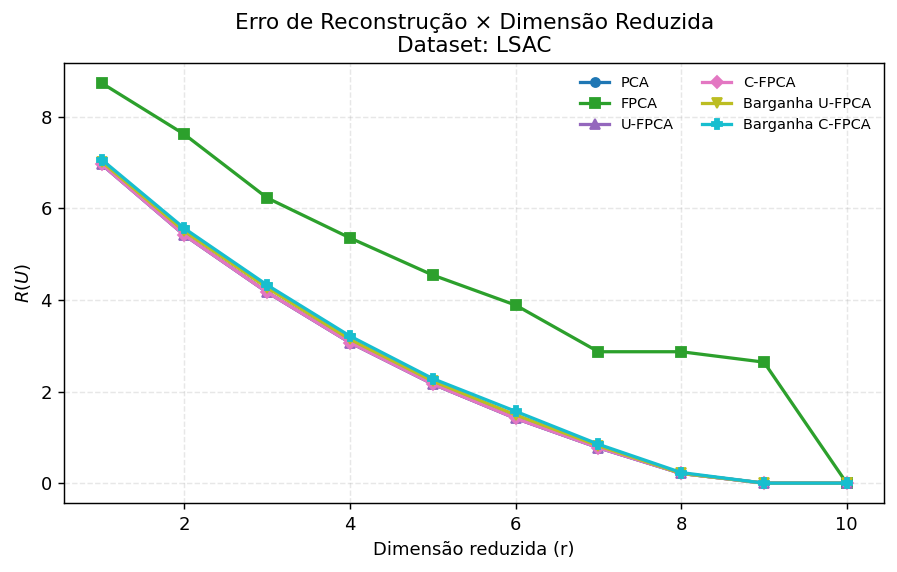

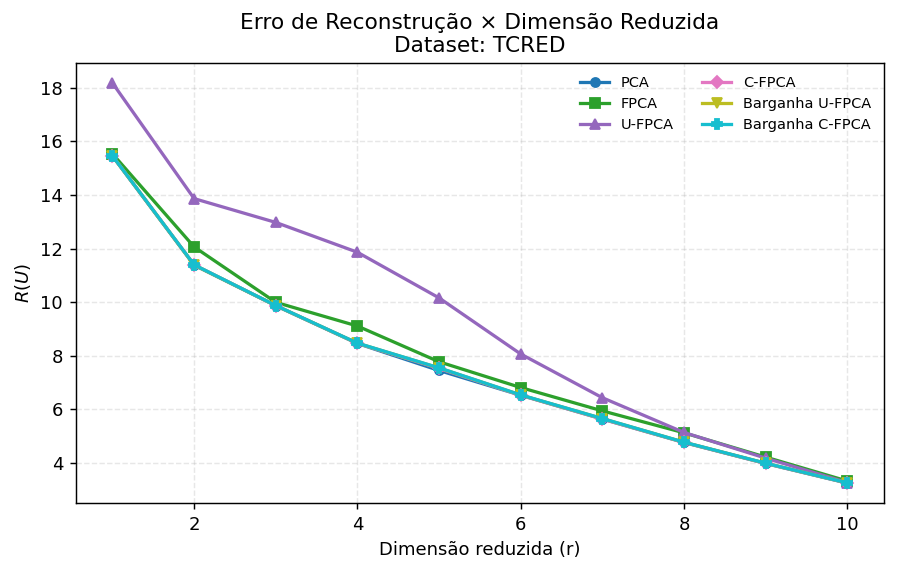

In [40]:
ALGOS_ORDEM = ["PCA", "FPCA", "U-FPCA", "C-FPCA", "Barganha U-FPCA", "Barganha C-FPCA"]
CORES = plt.cm.tab10(np.linspace(0, 1, len(ALGOS_ORDEM)))
MARCADORES = ["o", "s", "^", "D", "v", "P"]

def plot_metrica(df_res, coluna, titulo, ylabel, nome_dataset):
    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=130)
    for algo, cor, mk in zip(ALGOS_ORDEM, CORES, MARCADORES):
        sub = df_res[df_res["algoritmo"] == algo].sort_values("r")
        if sub.empty:
            continue
        ax.plot(sub["r"], sub[coluna], marker=mk, color=cor, label=algo,
                linewidth=1.8, markersize=5)
    ax.set_xlabel("Dimensão reduzida (r)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{titulo}\nDataset: {nome_dataset}")
    ax.legend(frameon=False, fontsize=8, ncol=2)
    ax.grid(alpha=0.3, linestyle="--")
    fig.tight_layout()
    plt.show()


for nome_dataset, res in resultados_por_dataset.items():
    plot_metrica(res["df"], "R", "Erro de Reconstrução × Dimensão Reduzida",
                 r"$R(U)$", nome_dataset)


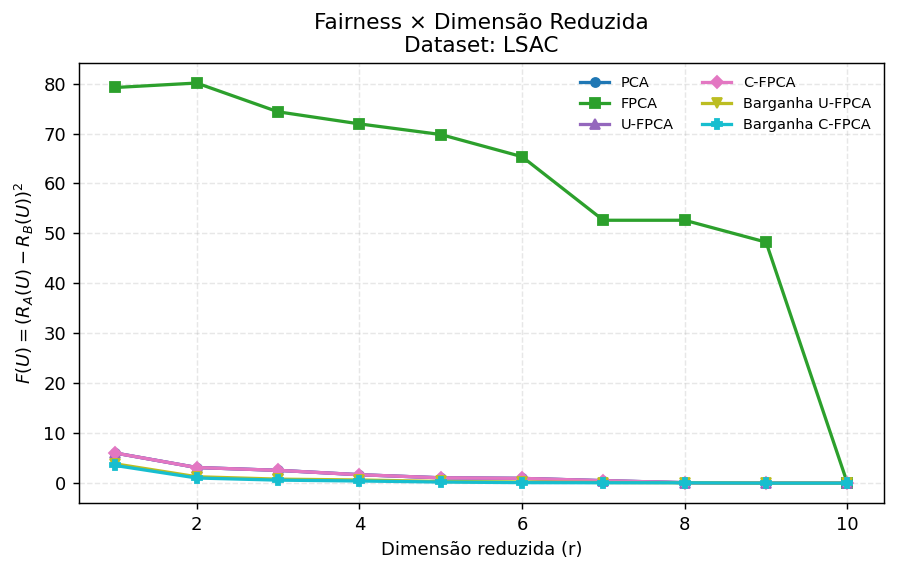

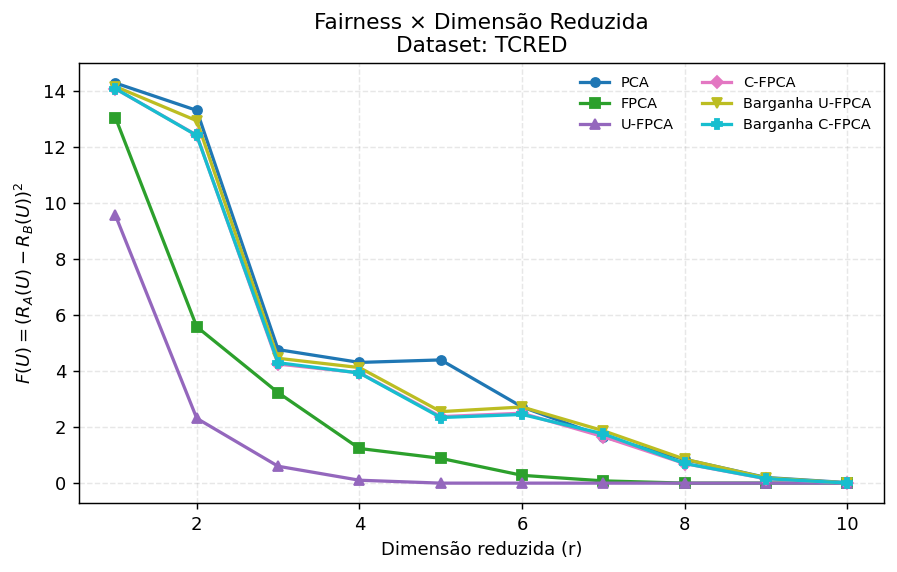

In [41]:
for nome_dataset, res in resultados_por_dataset.items():
    plot_metrica(res["df"], "F", "Fairness × Dimensão Reduzida",
                 r"$F(U) = \left(R_A(U) - R_B(U)\right)^2$", nome_dataset)


### 14.1 (Opcional) α por dimensão — U-FPCA vs. peso endógeno da Barganha

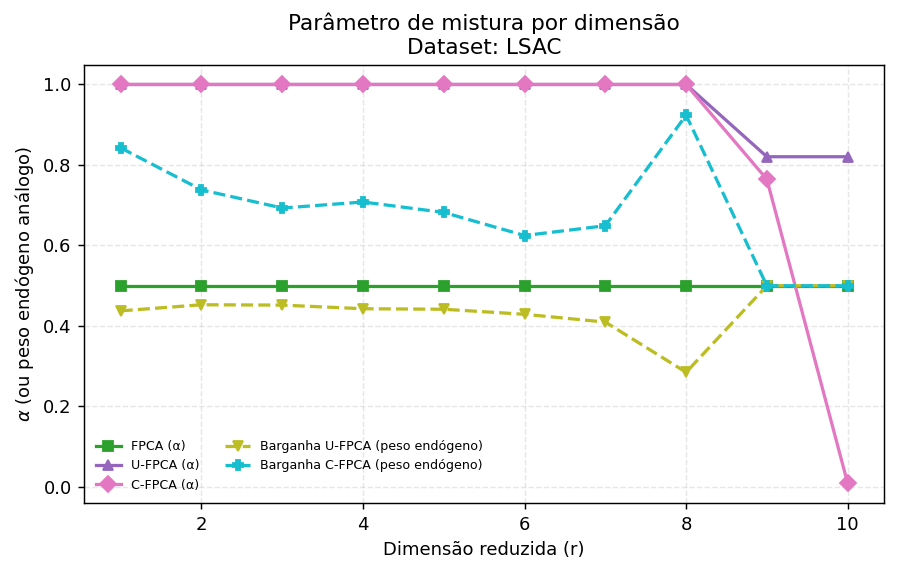

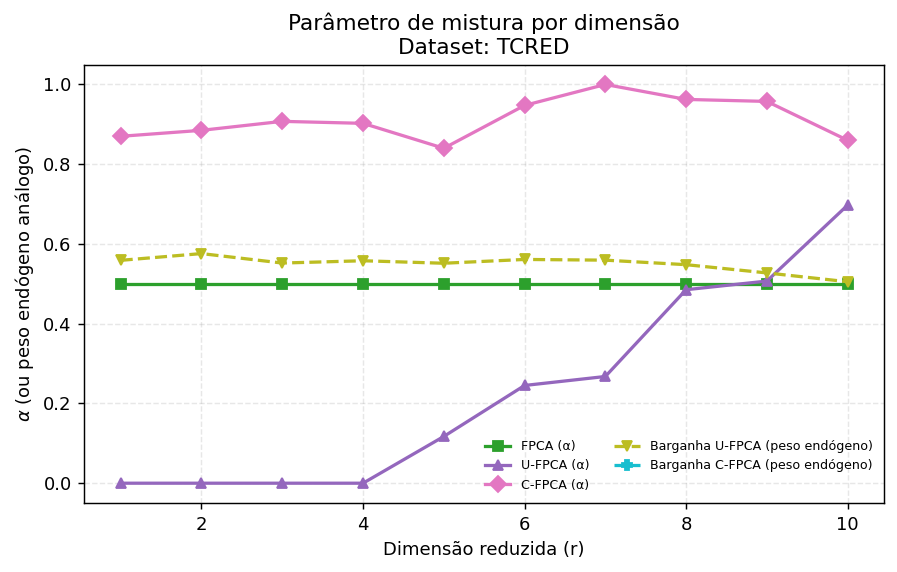

In [42]:
def plot_alpha(df_res, nome_dataset):
    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=130)
    for algo, cor, mk in zip(["FPCA", "U-FPCA", "C-FPCA"], CORES[1:4], MARCADORES[1:4]):
        sub = df_res[df_res["algoritmo"] == algo].sort_values("r")
        ax.plot(sub["r"], sub["alpha"], marker=mk, color=cor, label=f"{algo} (α)", linewidth=1.8)
    for algo, cor, mk in zip(["Barganha U-FPCA", "Barganha C-FPCA"], CORES[4:], MARCADORES[4:]):
        sub = df_res[df_res["algoritmo"] == algo].sort_values("r")
        ax.plot(sub["r"], sub["alpha"], marker=mk, color=cor, linestyle="--",
                 label=f"{algo} (peso endógeno)", linewidth=1.8)
    ax.set_xlabel("Dimensão reduzida (r)")
    ax.set_ylabel(r"$\alpha$ (ou peso endógeno análogo)")
    ax.set_title(f"Parâmetro de mistura por dimensão\nDataset: {nome_dataset}")
    ax.legend(frameon=False, fontsize=7, ncol=2)
    ax.grid(alpha=0.3, linestyle="--")
    fig.tight_layout()
    plt.show()


for nome_dataset, res in resultados_por_dataset.items():
    plot_alpha(res["df"], nome_dataset)


### 14.2 (Opcional) Evolução da função objetivo dos modelos de barganha

Para cada algoritmo de barganha, escolhemos o valor de `r` com o **histórico
mais longo** (mais passos de gradiente) entre os `r` testados — em dimensões
muito altas (próximas de `d`) o erro de reconstrução tende a zero e a
otimização converge em 1 passo, o que deixaria o gráfico vazio se o `r`
escolhido fosse sempre o máximo.


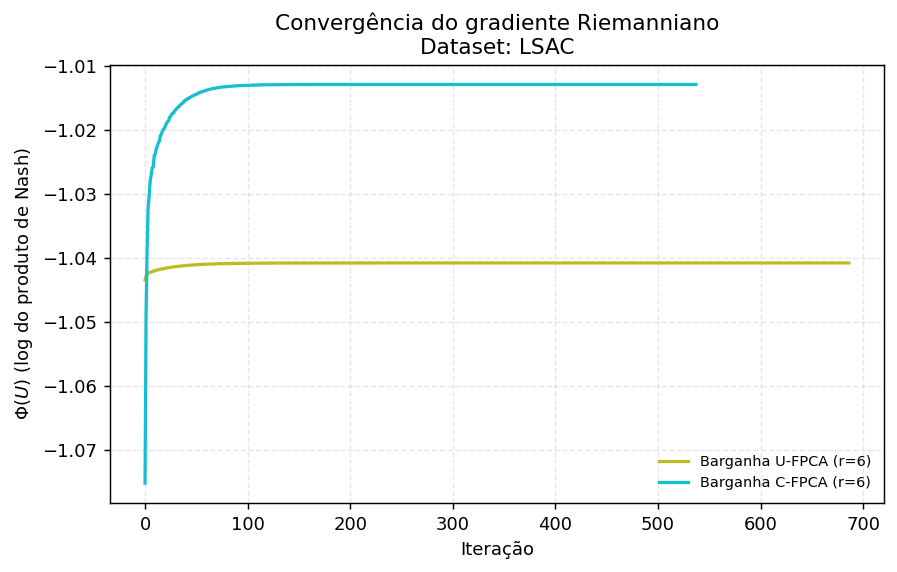

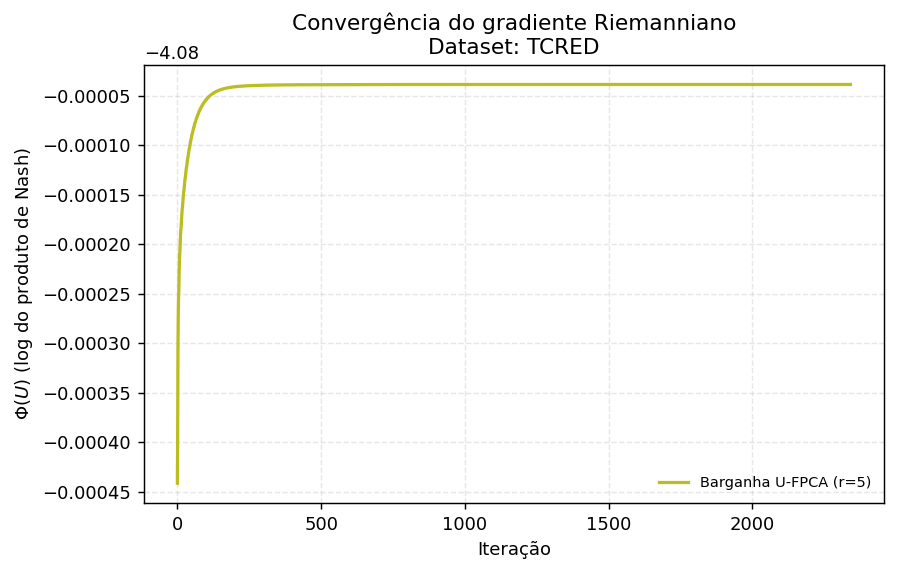

In [43]:
def escolher_r_mais_informativo(hist_dict, algo, r_max):
    """Retorna o r (excluindo r_max, tipicamente trivial) com histórico mais
    longo para o algoritmo dado; usa r_max apenas se não houver outra opção."""
    candidatos = [(r, hist_dict.get((algo, r), np.array([])))
                  for r in range(1, r_max)]  # exclui r_max de propósito
    candidatos = [(r, h) for r, h in candidatos if h.size > 1]
    if not candidatos:
        h = hist_dict.get((algo, r_max), np.array([]))
        return (r_max, h) if h.size > 1 else (None, np.array([]))
    return max(candidatos, key=lambda rc: rc[1].size)


def plot_convergencia(hist_dict, r_max, nome_dataset):
    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=130)
    algo_plotado = False
    for algo, cor in zip(["Barganha U-FPCA", "Barganha C-FPCA"], CORES[4:]):
        r_escolhido, hist = escolher_r_mais_informativo(hist_dict, algo, r_max)
        if hist.size > 1:
            ax.plot(hist, color=cor, label=f"{algo} (r={r_escolhido})", linewidth=1.8)
            algo_plotado = True
    ax.set_xlabel("Iteração")
    ax.set_ylabel(r"$\Phi(U)$ (log do produto de Nash)")
    ax.set_title(f"Convergência do gradiente Riemanniano\nDataset: {nome_dataset}")
    if algo_plotado:
        ax.legend(frameon=False, fontsize=8)
    else:
        ax.text(0.5, 0.5, "Nenhum histórico com mais de 1 iteração\n"
                           "(otimização convergiu imediatamente em todos os r)",
                ha="center", va="center", transform=ax.transAxes, fontsize=9)
    ax.grid(alpha=0.3, linestyle="--")
    fig.tight_layout()
    plt.show()


for nome_dataset, res in resultados_por_dataset.items():
    plot_convergencia(res["hist"], res["dados"]["r_max"], nome_dataset)


### 14.3 (Opcional) Tempo de execução por algoritmo

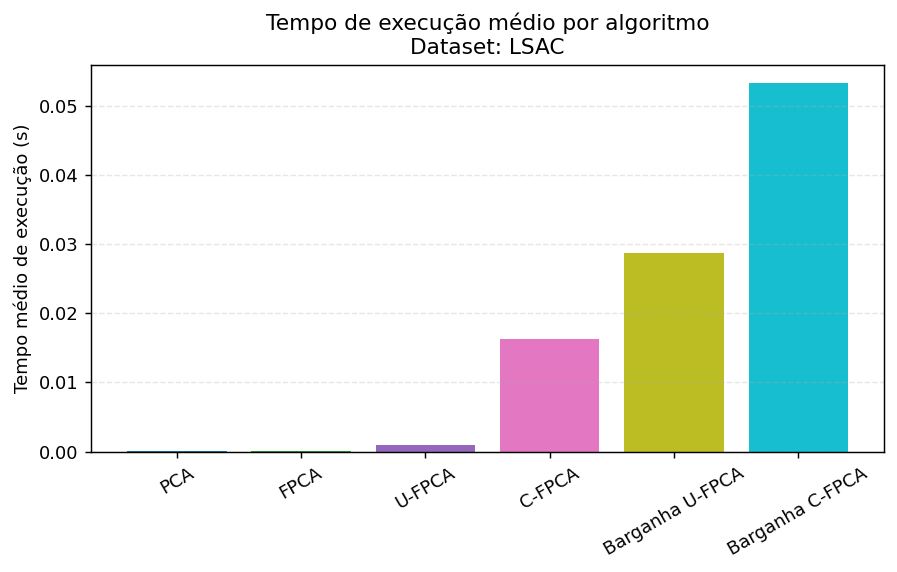

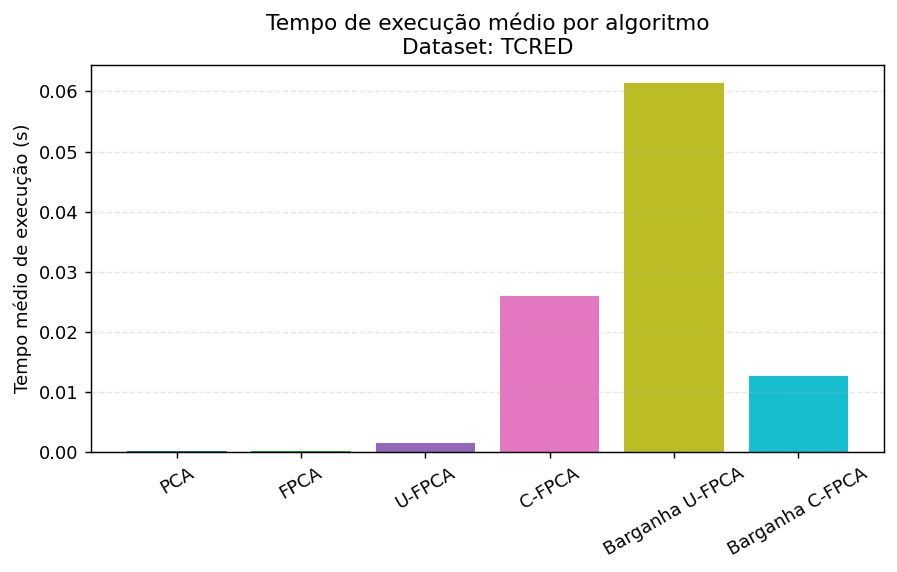

In [44]:
def plot_tempo(df_res, nome_dataset):
    tempo_medio = (df_res.groupby("algoritmo")["tempo"].mean().reindex(ALGOS_ORDEM))
    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=130)
    ax.bar(tempo_medio.index, tempo_medio.values, color=CORES)
    ax.set_ylabel("Tempo médio de execução (s)")
    ax.set_title(f"Tempo de execução médio por algoritmo\nDataset: {nome_dataset}")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(alpha=0.3, linestyle="--", axis="y")
    fig.tight_layout()
    plt.show()


for nome_dataset, res in resultados_por_dataset.items():
    plot_tempo(res["df"], nome_dataset)


## 15. Tabelas finais

Para cada dataset: tabela completa (todos os `r`) e tabela-resumo com os
valores finais (R_A, R_B, R, fairness F = D², α) na maior dimensão testada,
útil para compor a tabela comparativa do artigo. As tabelas ficam apenas
no notebook (nenhum arquivo CSV é gerado).


In [45]:
for nome_dataset, res in resultados_por_dataset.items():
    print(f"\n===== {nome_dataset}: tabela completa (todos os r) =====")
    tabela_completa = (res["df"]
                        .assign(algoritmo=lambda d: pd.Categorical(d["algoritmo"], ALGOS_ORDEM, ordered=True))
                        .sort_values(["r", "algoritmo"])
                        .reset_index(drop=True))
    display(tabela_completa.round(4))



===== LSAC: tabela completa (todos os r) =====


,algoritmo,r,R_A,R_B,R,F,alpha,tempo,viavel
0,PCA,1,6.7951,9.2500,6.9606,6.0265,NaN,0.0001,True
1,FPCA,1,8.1349,17.0355,8.7350,79.2197,0.5000,0.0000,True
2,U-FPCA,1,6.7951,9.2501,6.9606,6.0271,1.0000,0.0009,True
3,C-FPCA,1,6.7951,9.2500,6.9606,6.0265,1.0000,0.0171,True
4,Barganha U-FPCA,1,6.8874,8.8520,7.0198,3.8597,0.4376,0.0045,True
5,Barganha C-FPCA,1,6.9377,8.8175,7.0644,3.5337,0.8424,0.0070,True
6,PCA,2,5.2963,7.0640,5.4154,3.1250,NaN,0.0000,True
7,FPCA,2,7.0113,15.9618,7.6147,80.1130,0.5000,0.0000,True
8,U-FPCA,2,5.2962,7.0641,5.4154,3.1255,1.0000,0.0009,True
9,C-FPCA,2,5.2963,7.0640,5.4154,3.1250,1.0000,0.0165,True



===== TCRED: tabela completa (todos os r) =====


,algoritmo,r,R_A,R_B,R,F,alpha,tempo,viavel
0,PCA,1,17.8456,14.0672,15.4589,14.2769,NaN,0.0002,True
1,FPCA,1,17.8208,14.2093,15.5396,13.0428,0.5000,0.0001,True
2,U-FPCA,1,20.2223,17.1310,18.1794,9.5559,0.0000,0.0014,True
3,C-FPCA,1,17.8298,14.0786,15.4610,14.0714,0.8700,0.0263,False
4,Barganha U-FPCA,1,17.8343,14.0723,15.4609,14.1520,0.5590,0.0058,True
5,Barganha C-FPCA,1,17.8290,14.0770,15.4620,14.0768,NaN,0.0129,False
6,PCA,2,13.6793,10.0323,11.3866,13.3006,NaN,0.0001,True
7,FPCA,2,13.5496,11.1878,12.0656,5.5779,0.5000,0.0001,True
8,U-FPCA,2,14.8346,13.3142,13.8677,2.3118,0.0000,0.0015,True
9,C-FPCA,2,13.6097,10.0860,11.3948,12.4169,0.8850,0.0262,False


In [46]:
for nome_dataset, res in resultados_por_dataset.items():
    r_max_ds = res["dados"]["r_max"]
    print(f"\n===== {nome_dataset}: resumo final em r = {r_max_ds} =====")
    tabela_resumo = (res["df"][res["df"]["r"] == r_max_ds]
                      .assign(algoritmo=lambda d: pd.Categorical(d["algoritmo"], ALGOS_ORDEM, ordered=True))
                      .sort_values("algoritmo")
                      .set_index("algoritmo")[["R_A", "R_B", "R", "F", "alpha", "tempo", "viavel"]]
                      .round(4))
    display(tabela_resumo)



===== LSAC: resumo final em r = 10 =====


,R_A,R_B,R,F,alpha,tempo,viavel
algoritmo,,,,,,,
PCA,-0.0,-0.0,-0.0,0.0,NaN,0.0000,True
FPCA,0.0,0.0,0.0,0.0,0.5000,0.0000,True
U-FPCA,0.0,0.0,0.0,0.0,0.8205,0.0008,True
C-FPCA,0.0,0.0,0.0,0.0,0.0094,0.0158,True
Barganha U-FPCA,0.0,0.0,0.0,0.0,0.5000,0.0001,True
Barganha C-FPCA,-0.0,-0.0,-0.0,0.0,0.5000,0.0001,True



===== TCRED: resumo final em r = 10 =====


,R_A,R_B,R,F,alpha,tempo,viavel
algoritmo,,,,,,,
PCA,3.2625,3.1272,3.2521,0.0183,NaN,0.0000,True
FPCA,3.1973,3.2774,3.3306,0.0064,0.5000,0.0000,True
U-FPCA,3.1959,3.1959,3.2745,0.0000,0.6975,0.0014,True
C-FPCA,3.2190,3.1589,3.2573,0.0036,0.8600,0.0258,False
Barganha U-FPCA,3.2168,3.1498,3.2622,0.0045,0.5053,0.0350,True
Barganha C-FPCA,3.2158,3.1508,3.2625,0.0042,NaN,0.0126,False


---
### Observações finais

- A métrica de fairness usada em todo o notebook é **F(U) = D(U)² = (R_A(U) - R_B(U))²** — o quadrado da disparidade D(U) = R_A(U) - R_B(U) entre os erros de reconstrução dos dois grupos. É `F` que U-FPCA e C-FPCA minimizam, e é `F` que aparece nos gráficos e tabelas.
- **Fair PCA clássico** foi implementado com α fixo (0.5) como baseline "ingênuo" de mistura entre PCA e o termo de diferença de covariâncias — ajuste esse valor na Seção 8 caso seu enunciado defina outro critério para o α fixo.
- **C-FPCA** e **Barganha C-FPCA** usam τ = R_B(U_PCA) por dimensão `r`, conforme especificado. Se, para algum `r`, nenhuma solução estritamente viável for encontrada, a coluna `viavel` sinaliza `False`.
- Os pesos `w_A, w_B` da barganha de Nash (`BARGAIN_WEIGHTS`, Seção 3) representam o poder de barganha de cada grupo; `(0.5, 0.5)` corresponde à barganha simétrica clássica.
- Os dois datasets (`LSAC` e `TCRED`) são processados de forma independente — os resultados, gráficos e tabelas de um não interferem no outro. Para rodar só um deles, edite a lista `DATASETS` na Seção 3.
